# House Price Prediction

**Linear Regression** and **Decision Tree Regression**.

MAE/RMSE/R², an actual-versus-predicted plot, and Decision Tree feature importance.

**Dataset:** `Housing.csv`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Load and inspect the dataset


In [2]:
data = pd.read_csv("Housing.csv")

print("Dataset shape:", data.shape)
display(data.head())

Dataset shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580306e+09,5.400886e+05,3.370795,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876570e+09,3.671268e+05,0.930105,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## 2. Exploratory data analysis (EDA)


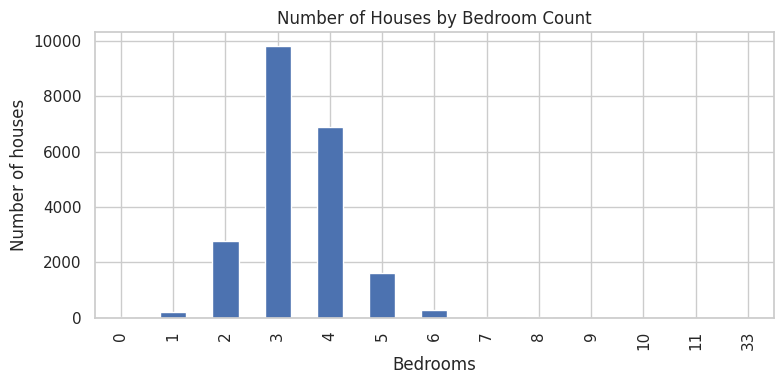

In [4]:
plt.figure(figsize=(8, 4))
data["bedrooms"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Houses by Bedroom Count")
plt.xlabel("Bedrooms")
plt.ylabel("Number of houses")
plt.tight_layout()
plt.show()

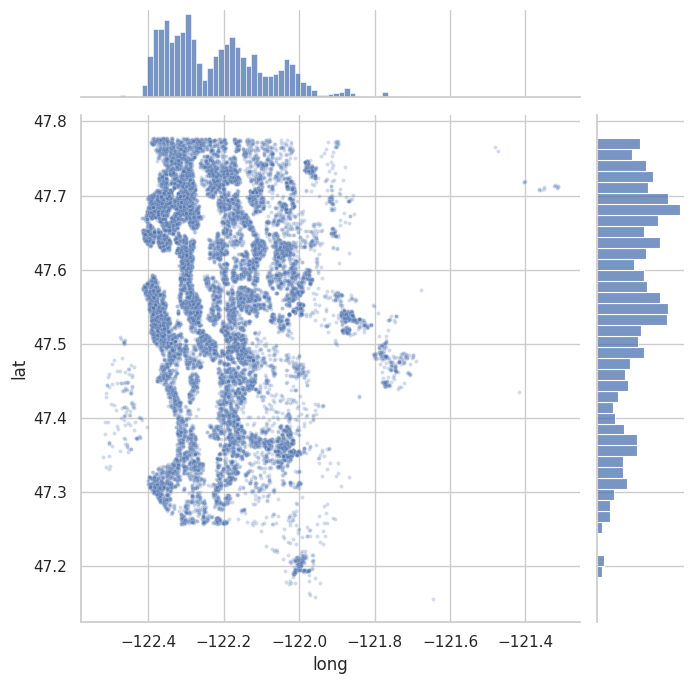

In [5]:
sns.jointplot(data=data, x="long", y="lat", height=7, alpha=0.25, s=8)
plt.show()

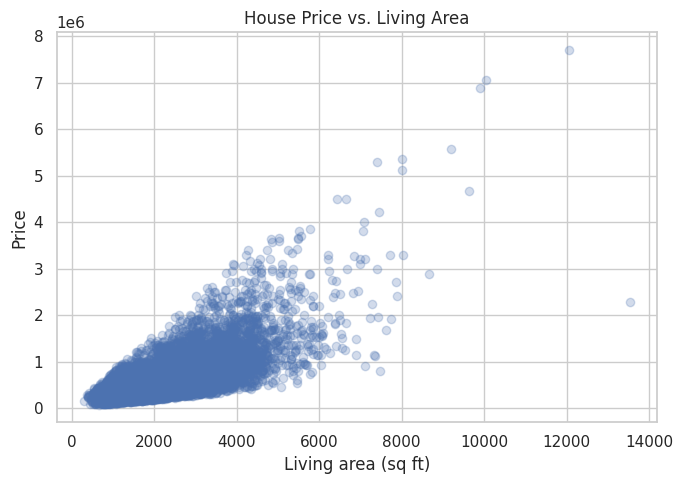

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(data["sqft_living"], data["price"], alpha=0.25)
plt.xlabel("Living area (sq ft)")
plt.ylabel("Price")
plt.title("House Price vs. Living Area")
plt.tight_layout()
plt.show()

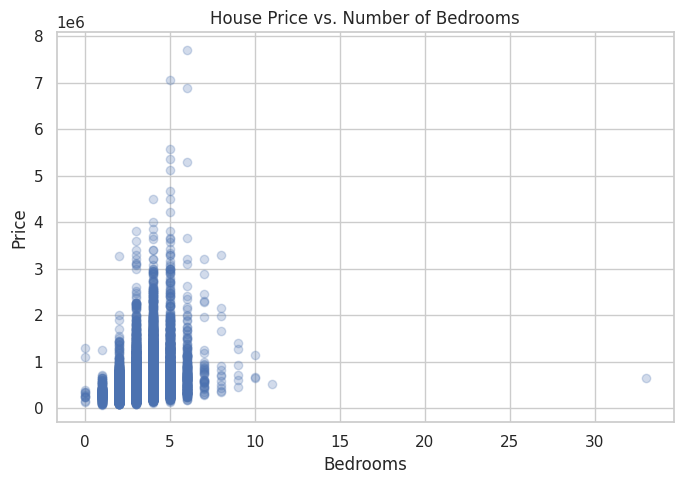

In [7]:
plt.figure(figsize=(7, 5))
plt.scatter(data["bedrooms"], data["price"], alpha=0.25)
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.title("House Price vs. Number of Bedrooms")
plt.tight_layout()
plt.show()

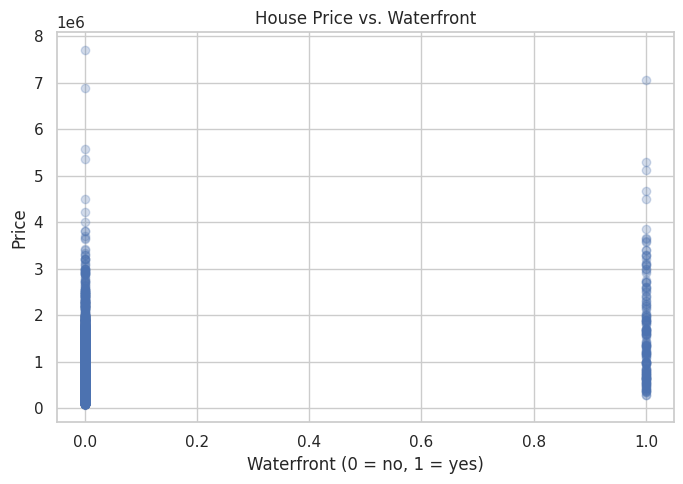

In [8]:
plt.figure(figsize=(7, 5))
plt.scatter(data["waterfront"], data["price"], alpha=0.25)
plt.xlabel("Waterfront (0 = no, 1 = yes)")
plt.ylabel("Price")
plt.title("House Price vs. Waterfront")
plt.tight_layout()
plt.show()

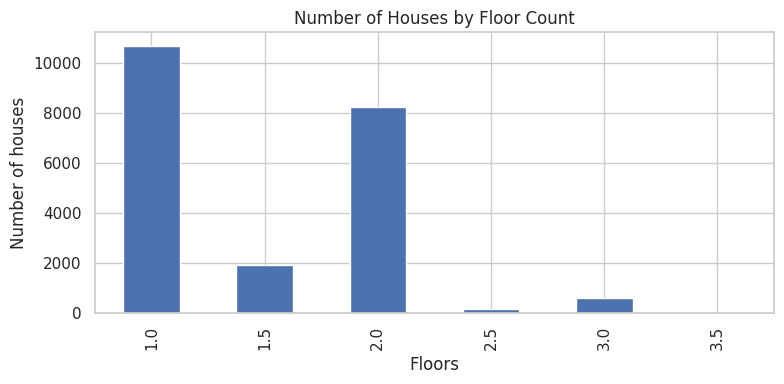

In [9]:
plt.figure(figsize=(8, 4))
data["floors"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Houses by Floor Count")
plt.xlabel("Floors")
plt.ylabel("Number of houses")
plt.tight_layout()
plt.show()

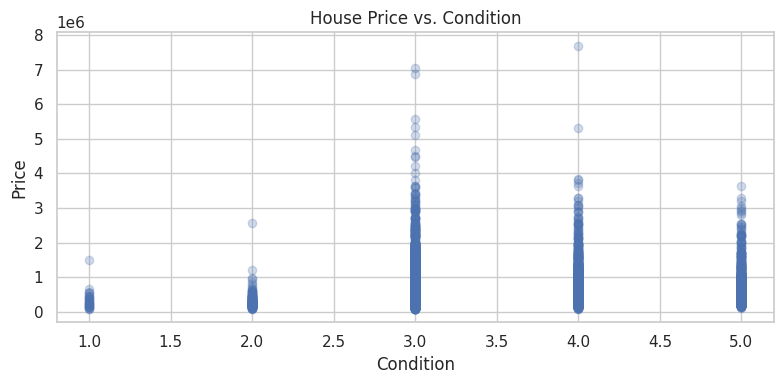

In [10]:
plt.figure(figsize=(8, 4))
plt.scatter(data["condition"], data["price"], alpha=0.25)
plt.xlabel("Condition")
plt.ylabel("Price")
plt.title("House Price vs. Condition")
plt.tight_layout()
plt.show()

## 3. Prepare features and target


In [11]:
data_model = data.copy()

if "date" in data_model.columns:
    parsed_date = pd.to_datetime(
        data_model["date"].astype(str),
        format="%Y%m%dT%H%M%S",
        errors="coerce"
    )
    if parsed_date.isna().all():
        parsed_date = pd.to_datetime(data_model["date"], errors="coerce")

    data_model["sale_year"] = parsed_date.dt.year
    data_model["sale_month"] = parsed_date.dt.month
    data_model = data_model.drop(columns=["date"])

y = data_model["price"]
X = data_model.drop(columns=["id", "price"], errors="ignore")

X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median())

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
display(X.head())

Feature matrix shape: (21613, 20)
Target shape: (21613,)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,2,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2


## 4. Split into training and testing sets


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=2
)

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows:  {len(X_test):,}")

Training rows: 19,451
Testing rows:  2,162


## 5. Train Linear Regression


In [13]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

## 6. Train Decision Tree Regression


In [14]:
tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

## 7. Compare model performance


In [15]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred),
    }

comparison = pd.DataFrame(
    {
        "Linear Regression": regression_metrics(y_test, linear_predictions),
        "Decision Tree": regression_metrics(y_test, tree_predictions),
    }
).T

display(comparison.round(3))

,MAE,RMSE,R²
Linear Regression,126472.074,197319.380,0.734
Decision Tree,117701.704,204395.641,0.714


## 8. Actual vs. predicted prices


This plot is for the Decision Tree model.


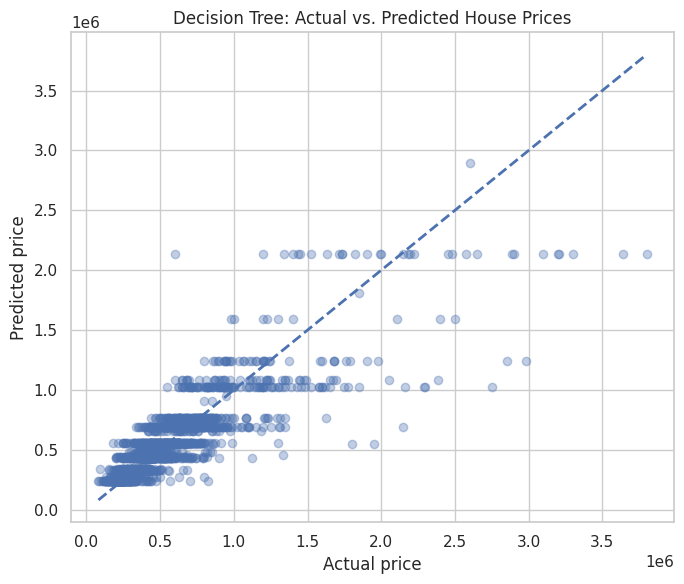

In [16]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, tree_predictions, alpha=0.35)

lower = min(y_test.min(), tree_predictions.min())
upper = max(y_test.max(), tree_predictions.max())
plt.plot([lower, upper], [lower, upper], linestyle="--", linewidth=2)

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Decision Tree: Actual vs. Predicted House Prices")
plt.tight_layout()
plt.show()

## 9. Decision Tree feature importance


,Importance
grade,0.444071
sqft_living,0.281137
lat,0.166083
long,0.032219
waterfront,0.027883
yr_built,0.026123
sqft_living15,0.012992
sqft_lot,0.008077
sqft_lot15,0.001319
zipcode,0.000096


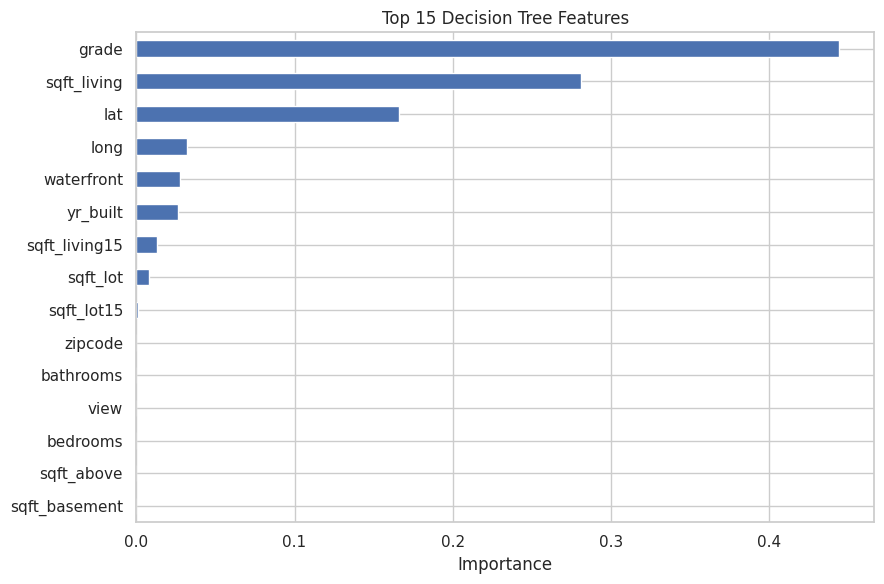

In [17]:
feature_importance = pd.Series(
    tree_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

display(feature_importance.head(15).to_frame("Importance"))

plt.figure(figsize=(9, 6))
feature_importance.head(15).sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 15 Decision Tree Features")
plt.tight_layout()
plt.show()

## 10. Optional: PCA exploration


Standardization is applied first because the features use different units.


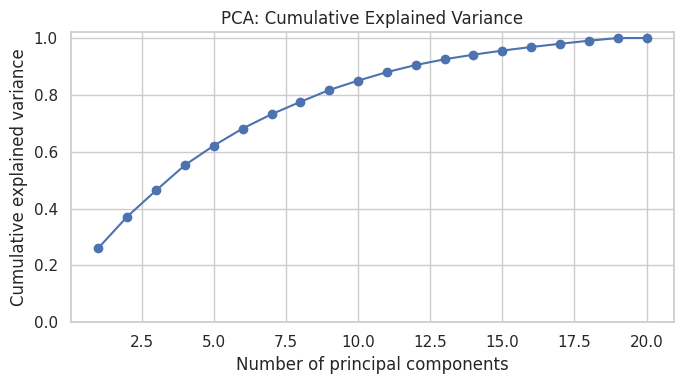

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA: Cumulative Explained Variance")
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()